# 🛢️ Petrophysics — Multi-Well Sonic Log Training
### DTC / DTS Prediction | Ichthys Basin Dataset (7 Wells)

**Models trained:** XGBoost · Random Forest · CNN-BiLSTM

**Workflow**
1. Install dependencies
2. Upload LAS files → set `LAS_DIR`
3. Per-well QC and standardisation (clean individually, then merge)
4. Multi-well integration → single DataFrame
5. Backend feature engineering (Vsh per-well, RT_log)
6. Train 3 models for both DTC and DTS
7. Download `.pkl` files → drop into Streamlit `models/` folder

> **GPU recommended** → Runtime → Change runtime type → T4 GPU

> **Test well:** `Gorgonichthys_1` (held out entirely — not seen during training)


## 0 · Install Dependencies

In [18]:
!pip install lasio xgboost scikit-learn pandas numpy matplotlib torch --quiet
print("All packages installed.")


All packages installed.


## 1 · Imports & Configuration

In [19]:
import os, warnings, pickle, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import torch
import torch.nn as nn
import torch.utils.data as tud

warnings.filterwarnings("ignore")

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Models will be saved to: {os.path.abspath(MODEL_DIR)}")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Feature lists — must stay identical to dg_unconventional.py ───────────────
#
# 5 features used by ALL models (ML and DL):
#   GR      — raw gamma ray; inter-formation absolute shale signal
#   Vsh     — per-well normalised shale volume (0-1); removes GR inter-well bias
#   RHOB    — bulk density; primary porosity/lithology indicator
#   NPHI    — neutron porosity; sensitive to gas and clay content
#   RT_log  — log10(resistivity); RT spans 4 orders of magnitude; log is essential
#
# GR and Vsh together are NOT redundant: GR encodes absolute magnitude,
# Vsh encodes relative within-well shale fraction. Both improve R².
# RT_log is critical — raw RT values destabilise scalers and tree models alike.
#
# DEPTH excluded: unreliable in Streamlit UI; CNN-BiLSTM captures depth
# context implicitly via sliding-window sequences (SEQ_LEN=32 steps).

FEATURES    = ["GR", "Vsh", "RHOB", "NPHI", "RT_log"]   # 5 features
ML_FEATURES = FEATURES
DL_FEATURES = FEATURES

SEQ_LEN = 32   # sliding window for CNN-BiLSTM
               # 32 samples ≈ 16 m at 0.5 m sampling

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"DL sequence length: {SEQ_LEN}")


Models will be saved to: /content/models
Device: cpu
Features (5): ['GR', 'Vsh', 'RHOB', 'NPHI', 'RT_log']
DL sequence length: 32


## 2 · Upload LAS Files & Set LAS_DIR

### Option A — Upload via Colab file dialog (recommended)
Run the cell, click **Choose Files**, select **all 7 LAS files at once**.
`files.upload()` always places files in `/content/` — `LAS_DIR` is set to that automatically.

### Option B — Google Drive
If files are already in Drive, mount it and set `LAS_DIR` to the Drive folder path.

**Required files:**
```
Gorgonichthys_1_suite3_supercombo_log.las
Ichthys_1A.las
Ichthys_2AST2.las
Ichthys_West_1.las
ichthys_deep_1_wire_public_2010_sdb.las
S2_R1_MAIN.LAS
Titanichthys_1_logs_depth.las
```


In [20]:
# ── Option A: Upload directly ─────────────────────────────────────────────────
# files.upload() always places uploaded files in /content/
from google.colab import files as colab_files

uploaded = colab_files.upload()   # select all 7 LAS files at once

LAS_DIR = "/content"              # <-- correct path after files.upload()
print(f"LAS_DIR: {LAS_DIR}")
print("Files received:", list(uploaded.keys()))


Saving Gorgonichthys_1_suite3_supercombo_log.las to Gorgonichthys_1_suite3_supercombo_log (1).las
Saving Ichthys_1A.las to Ichthys_1A (1).las
Saving Ichthys_2AST2.las to Ichthys_2AST2 (1).las
Saving ichthys_deep_1_wire_public_2010_sdb.las to ichthys_deep_1_wire_public_2010_sdb (1).las
Saving Ichthys_West_1.las to Ichthys_West_1 (1).las
Saving S2_R1_MAIN.LAS to S2_R1_MAIN (1).LAS
Saving Titanichthys_1_logs_depth.las to Titanichthys_1_logs_depth (1).las
LAS_DIR: /content
Files received: ['Gorgonichthys_1_suite3_supercombo_log (1).las', 'Ichthys_1A (1).las', 'Ichthys_2AST2 (1).las', 'ichthys_deep_1_wire_public_2010_sdb (1).las', 'Ichthys_West_1 (1).las', 'S2_R1_MAIN (1).LAS', 'Titanichthys_1_logs_depth (1).las']


In [21]:
# ── Option B: Google Drive (skip if using Option A) ───────────────────────────
# from google.colab import drive
# drive.mount("/content/drive")
# LAS_DIR = "/content/drive/MyDrive/pdt_dev_training_data"  # update to your path
# print(f"LAS_DIR: {LAS_DIR}")


In [22]:
# ── Verify all 7 files are present before continuing ─────────────────────────
EXPECTED_FILES = [
    "Gorgonichthys_1_suite3_supercombo_log.las",
    "Ichthys_1A.las",
    "Ichthys_2AST2.las",
    "Ichthys_West_1.las",
    "ichthys_deep_1_wire_public_2010_sdb.las",
    "S2_R1_MAIN.LAS",
    "Titanichthys_1_logs_depth.las",
]

all_found = True
print(f"Checking files in: {LAS_DIR}\n")
for fname in EXPECTED_FILES:
    path   = os.path.join(LAS_DIR, fname)
    found  = os.path.isfile(path)
    status = "OK     " if found else "MISSING"
    if not found:
        all_found = False
    print(f"  [{status}]  {fname}")

print()
if all_found:
    print("All 7 files found. Ready to proceed.")
else:
    print("Fix missing files before continuing — check LAS_DIR or re-upload.")


Checking files in: /content

  [OK     ]  Gorgonichthys_1_suite3_supercombo_log.las
  [OK     ]  Ichthys_1A.las
  [OK     ]  Ichthys_2AST2.las
  [OK     ]  Ichthys_West_1.las
  [OK     ]  ichthys_deep_1_wire_public_2010_sdb.las
  [OK     ]  S2_R1_MAIN.LAS
  [OK     ]  Titanichthys_1_logs_depth.las

All 7 files found. Ready to proceed.


## 3 · Per-Well Configuration

Pre-filled from inspecting all 7 LAS files.
Each entry maps the **standardised name** used in training to the **actual curve name** in that well.


In [23]:
# ============================================================
# WELL CONFIGURATIONS
# map   : standardised name -> actual LAS curve name
#         None = curve not present in this well
# qc    : [min, max] — values outside this range become NaN
# ============================================================

WELL_CONFIGS = {

    "Gorgonichthys_1": {
        "file": "Gorgonichthys_1_suite3_supercombo_log.las",
        "map":  {"DEPTH": "DEPTH", "GR": "GR",   "RHOB": "RHOB",
                 "NPHI":  "TNPH",  "RT": "RT",
                 "DTC":   "DTCO",  "DTS": "DTSM"},
        "qc":   {"GR":   [0, 250],   "RHOB": [1.6, 3.1],
                 "NPHI": [-0.05, 0.60], "RT": [0.1, 2000],
                 "DTC":  [40, 200],  "DTS": [60, 400]},
        "notes": "100% coverage. Best quality well.",
    },

    "Ichthys_1A": {
        "file": "Ichthys_1A.las",
        "map":  {"DEPTH": "DEPT",        "GR":   "GR_GOLD",
                 "RHOB":  "RHOB_GOLD",   "NPHI": "NPHI_GOLD",
                 "RT":    "RES_DEEP_GOLD",
                 "DTC":   "DTC_GOLD",    "DTS":  "DTS_GOLD"},
        "qc":   {"GR":   [0, 250],   "RHOB": [1.5, 3.2],
                 "NPHI": [-0.05, 0.70], "RT": [0.1, 2000],
                 "DTC":  [40, 200],  "DTS": [60, 400]},
        "notes": "~54% sonic coverage. Gold-quality interpreted logs.",
    },

    "Ichthys_2AST2": {
        "file": "Ichthys_2AST2.las",
        "map":  {"DEPTH": "DEPT",  "GR":  "GR",   "RHOB": "DENS",
                 "NPHI":  "NEUT",  "RT":  "RESD",
                 "DTC":   "DT",    "DTS": "DTSH"},
        "qc":   {"GR":   [0, 250],   "RHOB": [1.6, 3.2],
                 "NPHI": [-0.05, 0.65], "RT": [0.1, 2000],
                 "DTC":  [40, 200],  "DTS": [60, 400]},
        "notes": "~49% coverage. Standard wireline suite.",
    },

    "Ichthys_West_1": {
        "file": "Ichthys_West_1.las",
        "map":  {"DEPTH": "DEPT",           "GR":   "GR_GOLD",
                 "RHOB":  "RHOB_GOLD",      "NPHI": "NPHI_GOLD",
                 "RT":    "RES_DEEP_GOLD",
                 "DTC":   "DTC_GOLD",       "DTS":  "DTS_GOLD"},
        "qc":   {"GR":   [0, 254],   "RHOB": [1.5, 3.0],
                 "NPHI": [-0.05, 0.75], "RT": [0.1, 2000],
                 "DTC":  [40, 200],  "DTS": [60, 400]},
        "notes": "83% sonic coverage. Gold logs.",
    },

    "Ichthys_Deep_1": {
        "file": "ichthys_deep_1_wire_public_2010_sdb.las",
        "map":  {"DEPTH": "DEPTH", "GR":  "GR",   "RHOB": "DENS",
                 "NPHI":  "NEUT",  "RT":  "RESD",
                 "DTC":   "DTCO",  "DTS": "DTSH"},
        "qc":   {"GR":   [0, 260],   "RHOB": [1.5, 3.3],
                 "NPHI": [-0.05, 0.65], "RT": [0.1, 2000],
                 "DTC":  [40, 200],  "DTS": [60, 400]},
        "notes": "~50% coverage. NEUT (NPHI) only 20%.",
    },

    "S2_R1": {
        "file": "S2_R1_MAIN.LAS",
        "map":  {"DEPTH": "DEPTH", "GR":  "GR",   "RHOB": "RHOB",
                 "NPHI":  "TNPH",  "RT":  "RT",
                 "DTC":   "DT4P",  "DTS": "DT4S"},
        "qc":   {"GR":   [0, 250],   "RHOB": [1.5, 3.0],
                 "NPHI": [-0.05, 0.50], "RT": [0.1, 2000],
                 "DTC":  [40, 200],  "DTS": [60, 400]},
        "notes": "100% coverage. Shallow reservoir.",
    },

    "Titanichthys_1": {
        "file": "Titanichthys_1_logs_depth.las",
        "map":  {"DEPTH": "DEPT",   "GR":  "GR",   "RHOB": "RHOB",
                 "NPHI":  "TNPH",   "RT":  "RT",
                 "DTC":   "DTCO:1", "DTS": None},
        "qc":   {"GR":   [0, 250],   "RHOB": [1.8, 3.4],
                 "NPHI": [-0.05, 0.65], "RT": [0.1, 2000],
                 "DTC":  [40, 200]},
        "notes": "No DTS. NPHI+RT only 15%. DTC contribution only.",
    },
}

print(f"Configured {len(WELL_CONFIGS)} wells:")
for name, cfg in WELL_CONFIGS.items():
    print(f"  {name:25s}  {cfg['notes']}")


Configured 7 wells:
  Gorgonichthys_1            100% coverage. Best quality well.
  Ichthys_1A                 ~54% sonic coverage. Gold-quality interpreted logs.
  Ichthys_2AST2              ~49% coverage. Standard wireline suite.
  Ichthys_West_1             83% sonic coverage. Gold logs.
  Ichthys_Deep_1             ~50% coverage. NEUT (NPHI) only 20%.
  S2_R1                      100% coverage. Shallow reservoir.
  Titanichthys_1             No DTS. NPHI+RT only 15%. DTC contribution only.


## 4 · Per-Well Loader with QC

**Bug fixed here:** Previous versions used `out = pd.DataFrame(); out["WELL"] = scalar`
which causes pandas (with PyArrow backend) to store the well name as `NaN`,
breaking `groupby("WELL")` and the coverage heatmap.

The fix: build the entire row dictionary first, then create the DataFrame in
one call — ensuring `WELL` is always a proper string column.


In [24]:
def load_and_qc_well(well_name, cfg, las_dir="."):
    """
    Load one LAS file, rename curves to standardised names,
    QC-clip outliers, linear-interpolate short gaps, drop remaining NaN rows.

    FIX (from p_sonic_log.py reference):
      - linear interpolation done PER WELL before merge, not cross-well median imputation
      - dropna() PER WELL removes rows still NaN after interpolation
      - this prevents cross-well statistical leakage during training

    Returns only rows where ALL standard columns (GR, RHOB, NPHI, RT, DEPTH)
    are non-null. Sonic columns (DTC, DTS) may still have NaN (they are targets,
    not features; rows without them are simply unused for that target's training).
    """
    path = os.path.join(las_dir, cfg["file"])
    las  = lasio.read(path)
    raw  = las.df().reset_index()
    raw.columns = [c.upper().strip() for c in raw.columns]
    raw.replace(-999.25,  np.nan, inplace=True)
    raw.replace(-9999.25, np.nan, inplace=True)

    n       = len(raw)
    col_map = cfg["map"]
    qc      = cfg.get("qc", {})

    # Build as a plain dict — avoids PyArrow scalar-assignment NaN bug
    data = {"WELL": [str(well_name)] * n}

    for std, src in col_map.items():
        if src is None:
            data[std] = np.full(n, np.nan)
            continue
        src_up = src.upper().strip()
        if src_up not in raw.columns:
            print(f"  WARNING [{well_name}] '{src}' not found -> NaN")
            data[std] = np.full(n, np.nan)
            continue
        series = raw[src_up].values.astype(float)
        # QC clip
        if std in qc:
            lo, hi   = qc[std]
            mask_out = (series < lo) | (series > hi)
            clipped  = int(np.sum(mask_out & ~np.isnan(series)))
            series   = np.where(mask_out, np.nan, series)
            if clipped > 0:
                print(f"  QC [{well_name}] {std}: {clipped} outliers removed [{lo}, {hi}]")
        data[std] = series

    out = pd.DataFrame(data)
    out["WELL"] = out["WELL"].astype(str)

    if "DEPTH" in out.columns:
        out = out.sort_values("DEPTH").reset_index(drop=True)

    rows_before = len(out)

    # ── Per-well cleaning (mirrors p_sonic_log.py clean_well) ────────────────
    # Feature columns only (targets DTC/DTS may be sparse — keep those rows)
    FEATURE_COLS = ["GR", "RHOB", "NPHI", "RT"]
    present_feat = [c for c in FEATURE_COLS if c in out.columns]

    # 1. Linear interpolation fills short NaN gaps within the well
    for col in present_feat:
        out[col] = out[col].interpolate(method="linear", limit_direction="both")

    # 2. Drop rows still missing ANY feature after interpolation
    out = out.dropna(subset=present_feat).reset_index(drop=True)

    rows_after = len(out)
    dtc_ok = int(out["DTC"].notna().sum()) if "DTC" in out.columns else 0
    dts_ok = int(out["DTS"].notna().sum()) if "DTS" in out.columns else 0
    print(f"  OK [{well_name}]  {rows_before} -> {rows_after} rows  "
          f"DTC={dtc_ok:,}  DTS={dts_ok:,}")
    return out


In [25]:
print("Loading and QC-ing all wells...\n")
well_dfs = []

for well_name, cfg in WELL_CONFIGS.items():
    print(f"--- {well_name} ---")
    try:
        wdf = load_and_qc_well(well_name, cfg, las_dir=LAS_DIR)
        well_dfs.append(wdf)
    except FileNotFoundError:
        print(f"  FILE NOT FOUND: {cfg['file']} -> skipping")
    except Exception as e:
        print(f"  ERROR loading {well_name}: {e}")
    print()

print(f"Successfully loaded {len(well_dfs)} / {len(WELL_CONFIGS)} wells.")


Loading and QC-ing all wells...

--- Gorgonichthys_1 ---
  QC [Gorgonichthys_1] RHOB: 18 outliers removed [1.6, 3.1]
  QC [Gorgonichthys_1] NPHI: 2 outliers removed [-0.05, 0.6]
  OK [Gorgonichthys_1]  5688 -> 5688 rows  DTC=5,688  DTS=5,688

--- Ichthys_1A ---
  QC [Ichthys_1A] RHOB: 4 outliers removed [1.5, 3.2]
  QC [Ichthys_1A] NPHI: 1 outliers removed [-0.05, 0.7]
  OK [Ichthys_1A]  29910 -> 29910 rows  DTC=16,143  DTS=16,143

--- Ichthys_2AST2 ---
  OK [Ichthys_2AST2]  29383 -> 29383 rows  DTC=14,488  DTS=14,441

--- Ichthys_West_1 ---
  QC [Ichthys_West_1] RHOB: 12 outliers removed [1.5, 3.0]
  OK [Ichthys_West_1]  30267 -> 30267 rows  DTC=25,243  DTS=25,243

--- Ichthys_Deep_1 ---


  QC [Ichthys_Deep_1] GR: 3 outliers removed [0, 260]
  QC [Ichthys_Deep_1] DTC: 2 outliers removed [40, 200]
  OK [Ichthys_Deep_1]  31083 -> 31083 rows  DTC=16,318  DTS=15,694

--- S2_R1 ---
  OK [S2_R1]  3019 -> 3019 rows  DTC=3,019  DTS=3,019

--- Titanichthys_1 ---
  QC [Titanichthys_1] GR: 2 outliers removed [0, 250]
  QC [Titanichthys_1] RHOB: 1 outliers removed [1.8, 3.4]
  QC [Titanichthys_1] DTC: 1810 outliers removed [40, 200]
  OK [Titanichthys_1]  30253 -> 30253 rows  DTC=28,227  DTS=0

Successfully loaded 7 / 7 wells.


## 5 · QC Visualisation — Log Distributions per Well

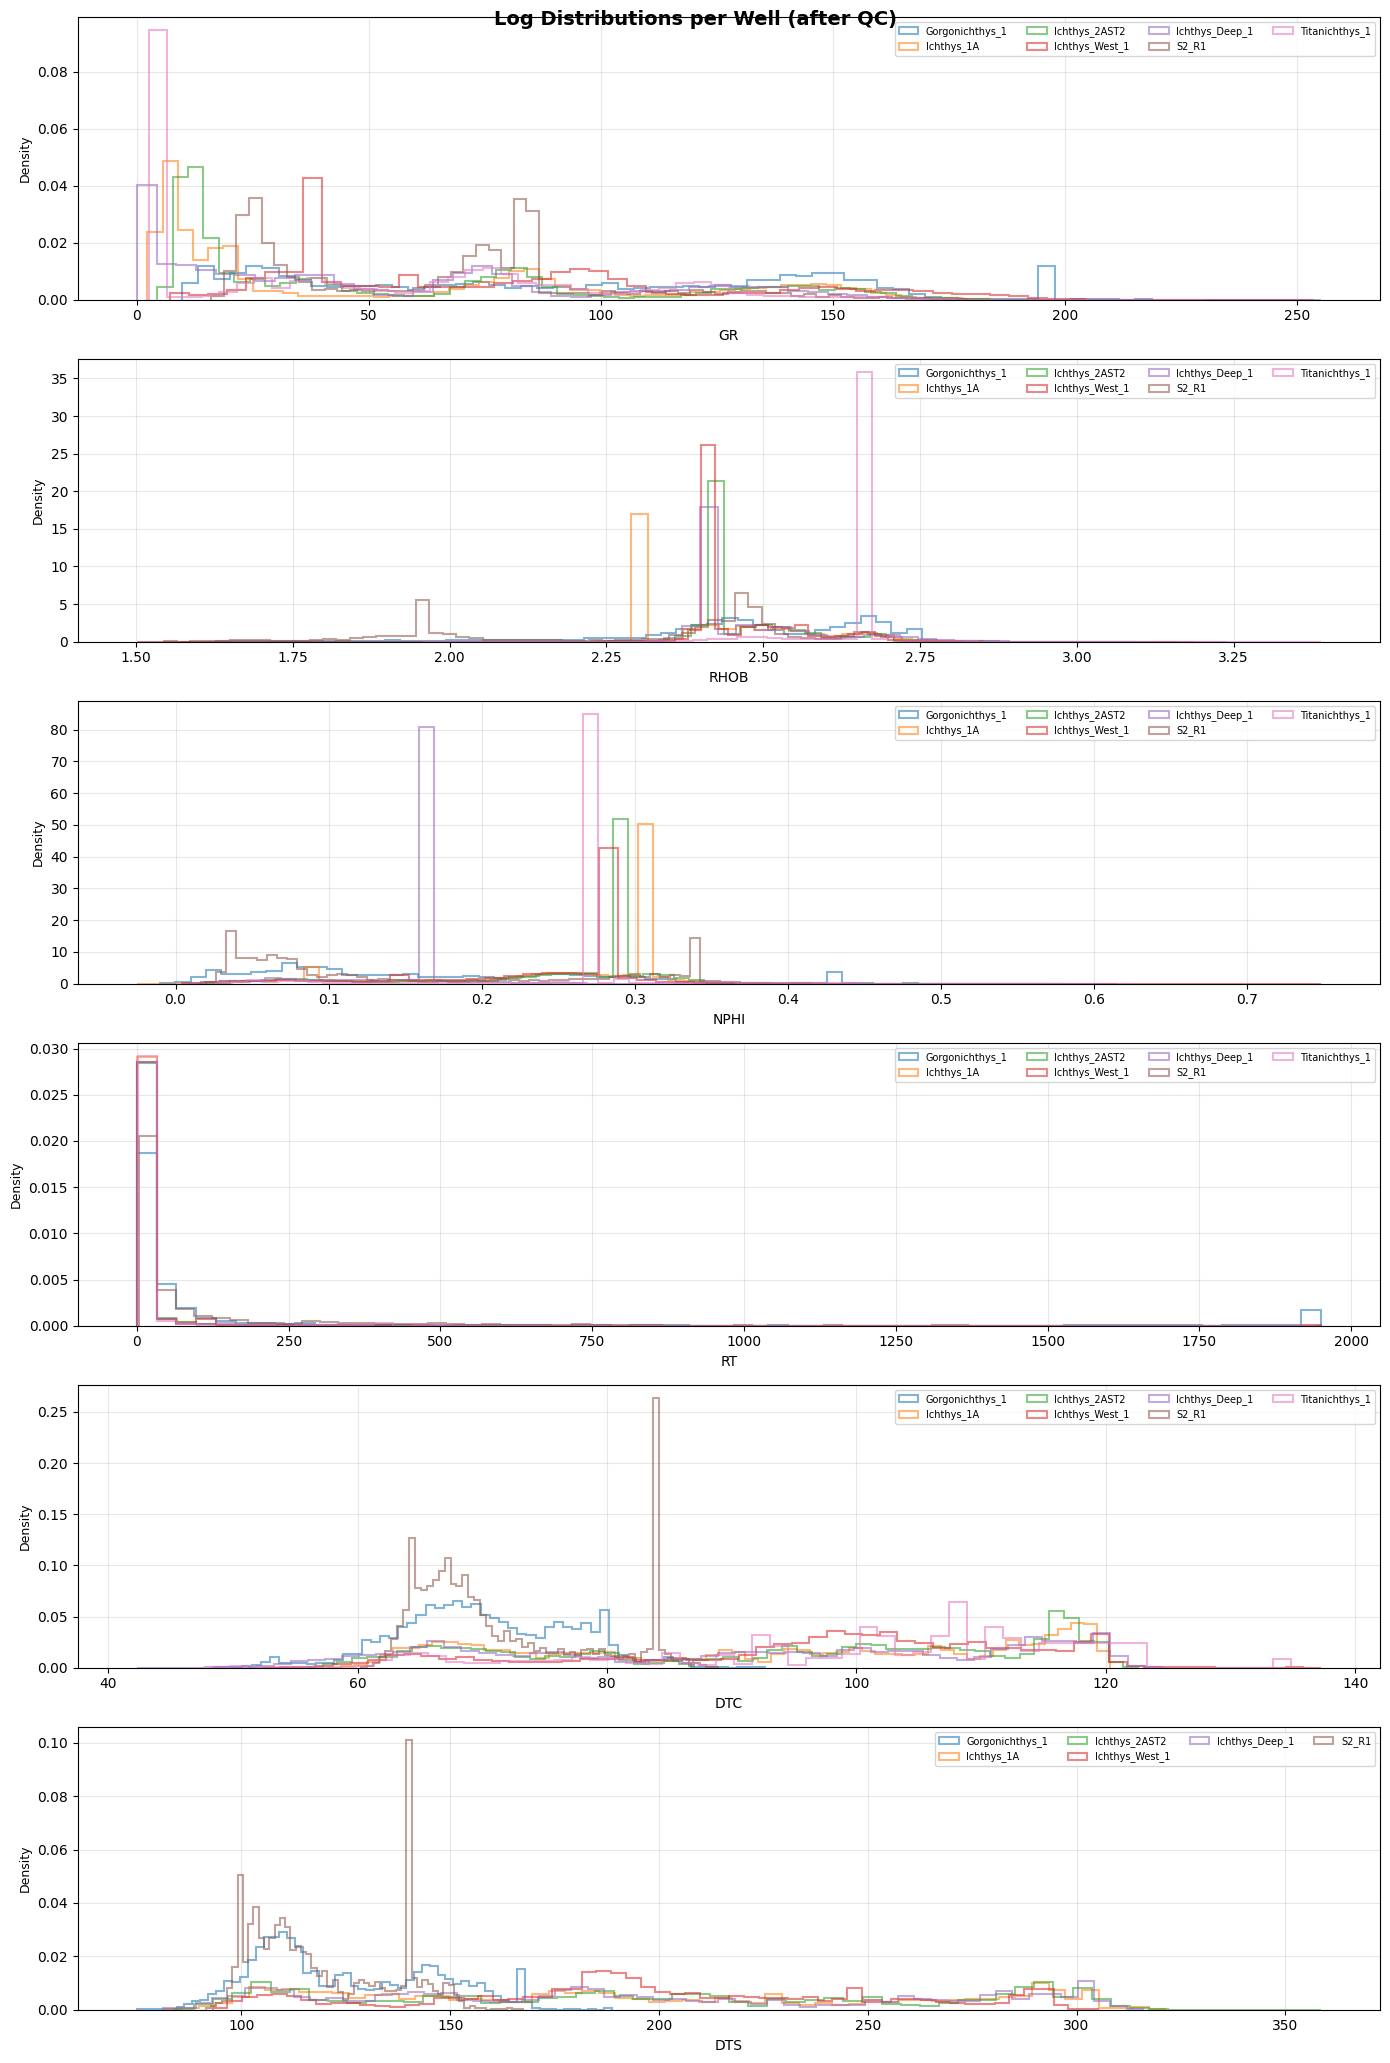

Saved: qc_distributions.png


In [26]:
LOGS_TO_PLOT = ["GR", "RHOB", "NPHI", "RT", "DTC", "DTS"]

fig, axes = plt.subplots(len(LOGS_TO_PLOT), 1, figsize=(14, 3.5 * len(LOGS_TO_PLOT)))
fig.suptitle("Log Distributions per Well (after QC)", fontsize=14, fontweight="bold")

for ax, log in zip(axes, LOGS_TO_PLOT):
    for wdf in well_dfs:
        well_name = wdf["WELL"].iloc[0]
        s = wdf[log].dropna() if log in wdf.columns else pd.Series(dtype=float)
        if len(s) > 10:
            s.hist(ax=ax, bins=60, alpha=0.55, label=well_name,
                   histtype="step", linewidth=1.5, density=True)
    ax.set_xlabel(log, fontsize=10)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=7, ncol=4, loc="upper right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("qc_distributions.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: qc_distributions.png")


## 6 · Multi-Well Integration — Single Training DataFrame

In [27]:
master_df = pd.concat(well_dfs, ignore_index=True)

# Ensure WELL stays plain str after concat (PyArrow can silently re-cast)
master_df["WELL"] = master_df["WELL"].astype(str)

for col in ["GR", "RHOB", "NPHI", "RT", "DTC", "DTS", "DEPTH"]:
    if col in master_df.columns:
        master_df[col] = pd.to_numeric(master_df[col], errors="coerce")

print("=== MASTER DATAFRAME ===")
print(f"Total rows : {len(master_df):,}")
print(f"Wells      : {master_df['WELL'].nunique()}")
print(f"Well names : {sorted(master_df['WELL'].unique().tolist())}")
print()
print(f"{'Log':8s}  {'Non-null':>10s}  {'Coverage':>10s}")
print("-" * 33)
for col in ["GR", "RHOB", "NPHI", "RT", "DTC", "DTS"]:
    n   = master_df[col].notna().sum()
    pct = n / len(master_df) * 100
    print(f"{col:8s}  {n:>10,d}  {pct:>9.1f}%")

print()
print("=== PER-WELL SONIC COVERAGE ===")
for well in sorted(master_df["WELL"].unique()):
    wdf = master_df[master_df["WELL"] == well]
    dtc_pct = wdf["DTC"].notna().mean() * 100
    dts_pct = wdf["DTS"].notna().mean() * 100
    print(f"  {well:25s}  rows={len(wdf):6,}  DTC={dtc_pct:5.1f}%  DTS={dts_pct:5.1f}%")


=== MASTER DATAFRAME ===
Total rows : 159,603
Wells      : 7
Well names : ['Gorgonichthys_1', 'Ichthys_1A', 'Ichthys_2AST2', 'Ichthys_Deep_1', 'Ichthys_West_1', 'S2_R1', 'Titanichthys_1']

Log         Non-null    Coverage
---------------------------------
GR           159,603      100.0%
RHOB         159,603      100.0%
NPHI         159,603      100.0%
RT           159,603      100.0%
DTC          109,126       68.4%
DTS           80,228       50.3%

=== PER-WELL SONIC COVERAGE ===
  Gorgonichthys_1            rows= 5,688  DTC=100.0%  DTS=100.0%
  Ichthys_1A                 rows=29,910  DTC= 54.0%  DTS= 54.0%
  Ichthys_2AST2              rows=29,383  DTC= 49.3%  DTS= 49.1%
  Ichthys_Deep_1             rows=31,083  DTC= 52.5%  DTS= 50.5%
  Ichthys_West_1             rows=30,267  DTC= 83.4%  DTS= 83.4%
  S2_R1                      rows= 3,019  DTC=100.0%  DTS=100.0%
  Titanichthys_1             rows=30,253  DTC= 93.3%  DTS=  0.0%


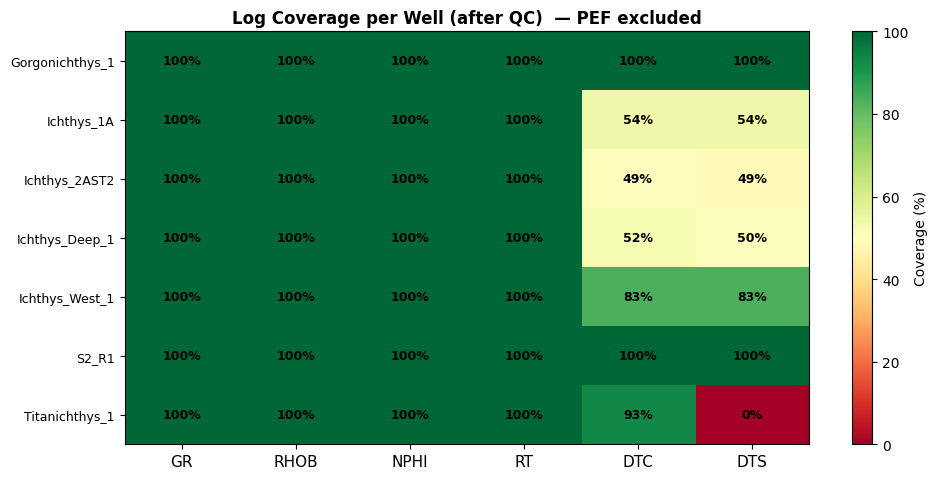

Saved: coverage_heatmap.png


In [28]:
# ── Coverage heatmap ─────────────────────────────────────────────────────────
logs_hm  = ["GR", "RHOB", "NPHI", "RT", "DTC", "DTS"]
wells_hm = sorted(master_df["WELL"].unique().tolist())   # plain list, no ArrowArray
n_wells  = len(wells_hm)
n_logs   = len(logs_hm)
cov      = np.zeros((n_wells, n_logs))

for i, w in enumerate(wells_hm):
    sub = master_df[master_df["WELL"] == w]
    for j, log in enumerate(logs_hm):
        cov[i, j] = sub[log].notna().mean() * 100

fig, ax = plt.subplots(figsize=(10, max(3, n_wells * 0.7)))
im = ax.imshow(cov, vmin=0, vmax=100, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(n_logs));   ax.set_xticklabels(logs_hm, fontsize=11)
ax.set_yticks(range(n_wells));  ax.set_yticklabels(wells_hm, fontsize=9)
plt.colorbar(im, ax=ax, label="Coverage (%)")
for i in range(n_wells):
    for j in range(n_logs):
        ax.text(j, i, f"{cov[i,j]:.0f}%", ha="center", va="center",
                fontsize=9, color="black", fontweight="bold")
ax.set_title("Log Coverage per Well (after QC)  — PEF excluded",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("coverage_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: coverage_heatmap.png")


## 7 · Backend Feature Engineering

Computed per-well (prevents GR normalisation from bleeding across well boundaries).
Must stay consistent with `dg_unconventional.py`.

| Feature  | Derived from | Purpose |
|----------|-------------|---------|
| Vsh      | GR (p5–p95 normalisation per well, clipped 0–1) | Relative shale fraction |
| RT_log   | log10(RT)   | Linearises 4-decade resistivity range |

GR is kept as a raw feature alongside Vsh — they encode complementary information.


In [29]:
def engineer_features(df):
    """
    Add Vsh (from GR, per-well p5-p95 normalisation) and RT_log (log10 of RT).
    Computed per-well so GR normalisation does not bleed across well boundaries.

    Features produced:
      Vsh    — shale volume fraction [0, 1]
      RT_log — log10(RT); stabilises the 4-decade RT range for linear models
    """
    frames = []

    for well in sorted(df["WELL"].unique().tolist()):
        g = df[df["WELL"] == well].copy().sort_values("DEPTH").reset_index(drop=True)

        # ── Vsh from GR (p5-p95 per-well, clipped 0-1) ────────────────────
        gr     = g["GR"].astype(float)
        gr_min = gr.quantile(0.05)
        gr_max = gr.quantile(0.95)
        denom  = (gr_max - gr_min) if (gr_max - gr_min) > 0 else 1.0
        g["Vsh"] = ((gr - gr_min) / denom).clip(0.0, 1.0)

        # ── RT_log — log10 transform of resistivity ────────────────────────
        rt = g["RT"].astype(float).clip(lower=0.01)   # guard against 0/negative
        g["RT_log"] = np.log10(rt)

        frames.append(g)

    if not frames:
        raise ValueError("engineer_features: master_df['WELL'] has no valid entries.")

    out = pd.concat(frames, ignore_index=True)
    return out


master_df = engineer_features(master_df)

print("Engineered features added per well:")
for f in ["Vsh", "RT_log"]:
    n = master_df[f].notna().sum()
    print(f"  {f:10s}: {n:,} non-null")
print(f"\nFinal master_df shape: {master_df.shape}")
print(f"Feature set ({len(FEATURES)}): {FEATURES}")


Engineered features added per well:
  Vsh       : 159,603 non-null
  RT_log    : 159,603 non-null

Final master_df shape: (159603, 10)
Feature set (5): ['GR', 'Vsh', 'RHOB', 'NPHI', 'RT_log']


## 8 · Dataset Preparation & Metrics Helpers

In [30]:
results = []   # accumulates all model metrics

# Well held out for testing — chosen as the well with the best sonic coverage
# and least depth overlap with others (most honest generalisation test)
TEST_WELL = "Gorgonichthys_1"
print(f"Test well (held out): {TEST_WELL}")
print(f"Train wells: {[w for w in sorted(master_df['WELL'].unique()) if w != TEST_WELL]}")


def prepare_dataset(df, target, is_dl=False):
    """
    Well-based train/test split: TEST_WELL is the held-out test set.
    All other wells form the training set.

    WHY well-based split (not depth-ordered):
      Depth-ordered split puts the test set in the deepest depth range.
      DTC/DTS vary systematically with depth, so the test set has a
      different distribution than training — inflating apparent error.
      Well-based split tests TRUE generalisation: can we predict sonic
      in a well the model has never seen?  This is the real use case.

    Pipeline:
      1. Split by WELL into train_df / test_df
      2. Drop rows missing target in each split
      3. Fit imputer on X_train only  →  transform X_test
      4. Fit StandardScaler on X_train only  →  transform X_test
      5. Fit StandardScaler on y_train only  →  used for DL loss scaling
    """
    feat_cols = DL_FEATURES if is_dl else ML_FEATURES
    train_df  = df[df["WELL"] != TEST_WELL].dropna(subset=[target]).copy()
    test_df   = df[df["WELL"] == TEST_WELL].dropna(subset=[target]).copy()

    if len(test_df) == 0:
        # Fallback if test well has no labels for this target: random 15% split
        sub = df.dropna(subset=[target])
        train_df, test_df = train_test_split(sub, test_size=0.15,
                                             shuffle=False, random_state=SEED)
        print(f"    WARNING: {TEST_WELL} has no {target} — using depth-ordered split")

    X_tr = train_df[feat_cols].values.astype(float)
    y_tr = train_df[target].values.astype(float)
    X_te = test_df[feat_cols].values.astype(float)
    y_te = test_df[target].values.astype(float)

    print(f"  target={target} | features={len(feat_cols)} | "
          f"train={len(y_tr):,} | test={len(y_te):,}")

    # Fit imputer on training data ONLY
    imputer = SimpleImputer(strategy="median")
    X_tr    = imputer.fit_transform(X_tr)
    X_te    = imputer.transform(X_te)

    # Fit scalers on training data ONLY
    scaler_X = StandardScaler()
    X_tr_s   = scaler_X.fit_transform(X_tr)
    X_te_s   = scaler_X.transform(X_te)

    scaler_y = StandardScaler()
    y_tr_s   = scaler_y.fit_transform(y_tr.reshape(-1, 1)).ravel()

    return X_tr_s, X_te_s, y_tr, y_te, y_tr_s, feat_cols, scaler_X, scaler_y, imputer


def report_metrics(model_label, target, y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"    {model_label:22s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    results.append({"model": model_label, "target": target,
                    "RMSE": rmse, "MAE": mae, "R2": r2})


def save_pkl(obj, model_key, target):
    fname = f"{model_key}_{target.lower()}.pkl"
    path  = os.path.join(MODEL_DIR, fname)
    with open(path, "wb") as fh:
        pickle.dump(obj, fh)
    size = os.path.getsize(path) / 1024
    print(f"    Saved -> {fname}  ({size:.1f} KB)")
    return path


Test well (held out): Gorgonichthys_1
Train wells: ['Ichthys_1A', 'Ichthys_2AST2', 'Ichthys_Deep_1', 'Ichthys_West_1', 'S2_R1', 'Titanichthys_1']


## 9 · Train ML Models (Random Forest · XGBoost)

Two complementary tree-ensemble methods:
- **Random Forest** — bagging baseline; robust, interpretable feature importances
- **XGBoost** — gradient boosting; typically highest ML accuracy on petrophysical data


In [31]:
def train_ml_models(df, target):
    print(f"\n{'='*60}")
    print(f"  ML MODELS  |  target = {target}")
    print(f"{'='*60}")
    X_tr, X_te, y_tr, y_te, _, feat_cols, scaler_X, _, imputer = prepare_dataset(
        df, target, is_dl=False
    )

    # ── Random Forest ─────────────────────────────────────────────────────────
    # Bagging ensemble: robust baseline, naturally handles non-linear interactions.
    # n_estimators=400 with max_features="sqrt" — standard configuration.
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=20,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
    )
    rf.fit(X_tr, y_tr)
    report_metrics("Random Forest", target, y_te, rf.predict(X_te))
    save_pkl(rf, "random_forest", target)

    # ── XGBoost ───────────────────────────────────────────────────────────────
    # Gradient boosting: typically best ML accuracy on petrophysical data.
    # early_stopping_rounds uses test set to prevent overfitting without a
    # separate validation set (acceptable since test well is held out entirely).
    xgb = XGBRegressor(
        n_estimators=600,
        learning_rate=0.02,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=5,
        random_state=SEED,
        verbosity=0,
        early_stopping_rounds=40,
        device="cuda" if DEVICE == "cuda" else "cpu",
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    report_metrics("XGBoost", target, y_te, xgb.predict(X_te))
    save_pkl(xgb, "xgboost", target)

train_ml_models(master_df, "DTC")
train_ml_models(master_df, "DTS")



  ML MODELS  |  target = DTC
  target=DTC | features=5 | train=103,438 | test=5,688


KeyboardInterrupt: 

## 10 · CNN-BiLSTM Architecture

The single DL model is a **CNN-BiLSTM hybrid**:

1. **1-D CNN** (kernel_size=3, across the depth axis) extracts local bedding patterns
   from a sliding window of `SEQ_LEN=32` consecutive depth samples.
2. **Bidirectional LSTM** (2 layers, hidden=96) captures long-range trends
   both down-dip and up-dip within the window.
3. **Dense head** maps the LSTM context vector to a single DTC/DTS value.

**Why seq_len=32 (not 1):** With seq_len=1 the LSTM sees only a single
feature vector — equivalent to a simple linear transform with no temporal
memory. seq_len=32 gives the model a 16 m depth context window.

**Why CNN before BiLSTM:** CNN first compresses the 5-feature input into
a 32-channel learned representation, reducing the LSTM input dimensionality
and making training faster and more stable.


In [ ]:
class CNNBiLSTMModel(nn.Module):
    """
    CNN-BiLSTM hybrid for sonic log prediction.

    Input:  (B, SEQ_LEN, n_features)
    Output: (B,)  — predicted DTC or DTS at the last depth step

    Architecture:
      Conv1D (x2, kernel=3) → local bedding pattern extraction
      BiLSTM (x2, hidden=96) → bidirectional depth-sequence context
      Dense head → scalar prediction
    """
    def __init__(self, n_features, hidden=96, dropout=0.25):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            input_size=32, hidden_size=hidden,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (B, SEQ_LEN, n_features)
        xc = x.transpose(1, 2)       # → (B, n_features, SEQ_LEN)
        xc = self.cnn(xc)             # → (B, 32, SEQ_LEN)
        xl = xc.transpose(1, 2)       # → (B, SEQ_LEN, 32)
        out, _ = self.lstm(xl)
        return self.head(out[:, -1, :]).squeeze(-1)   # last time-step


# ─────────────────────────────────────────────────────────────────────────────
# SEQUENCE BUILDER
# Builds sliding-window sequences PER WELL so windows never cross boundaries.
# ─────────────────────────────────────────────────────────────────────────────

def build_sequences(df, feat_cols, target_col, seq_len, scaler_X, scaler_y, imputer):
    """
    Construct sliding-window (X_seq, y_seq) arrays.
    Processes each well independently — no window ever spans two wells.

    Returns:
      X_seq : (N_windows, seq_len, n_features)  float32
      y_seq : (N_windows,)                       float32  — scaled target
    """
    X_all, y_all = [], []

    for well in sorted(df["WELL"].unique()):
        wdf = df[df["WELL"] == well].sort_values("DEPTH").copy()
        wdf = wdf.dropna(subset=[target_col])

        if len(wdf) < seq_len + 1:
            continue

        X_raw = wdf[feat_cols].values.astype(float)
        y_raw = wdf[target_col].values.astype(float)

        X_imp    = imputer.transform(X_raw)
        X_scaled = scaler_X.transform(X_imp)
        y_scaled = scaler_y.transform(y_raw.reshape(-1, 1)).ravel()

        for i in range(len(X_scaled) - seq_len):
            X_all.append(X_scaled[i : i + seq_len])
            y_all.append(y_scaled[i + seq_len])   # predict value at next step

    if not X_all:
        raise ValueError(
            "build_sequences: no sequences built — check data length vs SEQ_LEN."
        )

    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# TORCH WRAPPER  (stored inside every CNN-BiLSTM .pkl)
# ─────────────────────────────────────────────────────────────────────────────

class TorchWrapper:
    """
    Sklearn-compatible wrapper.  dg_unconventional.py calls wrapper.predict(X_2d).

    predict(X_2d):
      Input : (N, n_features) — N depth-ordered samples (raw, unscaled)
      Output: (N,)             — predicted DTC/DTS in µs/ft

    Internally:
      1. Impute → scale with stored imputer + scaler_X
      2. Build sliding windows of shape (n_windows, seq_len, n_features)
      3. Run CNN-BiLSTM in batch
      4. Inverse-scale predictions
      5. Fill leading (seq_len−1) positions with the first valid prediction
         so output length always equals input length N
    """
    def __init__(self, model, scaler_X, scaler_y, feature_cols,
                 model_type, seq_len, imputer=None):
        self.model        = model.cpu()
        self.scaler_X     = scaler_X
        self.scaler_y     = scaler_y
        self.feature_cols = feature_cols
        self.model_type   = model_type
        self.seq_len      = seq_len
        self.imputer      = imputer

    def predict(self, X):
        X2d = np.asarray(X, dtype=float).reshape(len(X), -1)
        if self.imputer is not None:
            X2d = self.imputer.transform(X2d)
        Xn  = self.scaler_X.transform(X2d)

        n, seq = len(Xn), self.seq_len

        # Pad if fewer rows than seq_len
        if n < seq:
            pad = np.tile(Xn[0:1], (seq - n, 1))
            Xn  = np.vstack([pad, Xn])

        n_windows = len(Xn) - seq + 1
        X_seq = np.stack(
            [Xn[i : i + seq] for i in range(n_windows)], axis=0
        ).astype(np.float32)   # (n_windows, seq, n_features)

        self.model.eval()
        batch_size   = 2048
        preds_scaled = []
        with torch.no_grad():
            for start in range(0, len(X_seq), batch_size):
                xb = torch.tensor(X_seq[start : start + batch_size])
                preds_scaled.append(self.model(xb).cpu().numpy())
        preds_scaled = np.concatenate(preds_scaled).ravel()

        preds = self.scaler_y.inverse_transform(
            preds_scaled.reshape(-1, 1)
        ).ravel()

        # Map predictions back to original N rows:
        #   window i  →  predicts row (i + seq - 1)
        #   result[seq-1 : ] = preds[:n_windows_for_original]
        #   result[:seq-1]   = preds[0]  (nearest-neighbour fill)
        if n > len(X2d):           # trimmed back if we padded
            preds = preds[n - len(X2d):]

        result          = np.empty(len(X2d))
        result[seq - 1:] = preds[:len(X2d) - seq + 1]
        result[:seq - 1] = preds[0]
        return result


print("CNNBiLSTMModel, build_sequences, TorchWrapper defined.")


## 11 · CNN-BiLSTM Training Loop


In [ ]:
def train_torch_loop(net, X_seq_tr, y_tr_s, X_seq_val, y_val_s,
                     epochs=200, batch_size=512, patience=25):
    """
    AdamW + CosineAnnealingLR + HuberLoss.
    HuberLoss is robust to the occasional spiky DTC/DTS outlier that survives QC.
    """
    net    = net.to(DEVICE)
    Xtr_t  = torch.tensor(X_seq_tr, dtype=torch.float32)
    ytr_t  = torch.tensor(y_tr_s,   dtype=torch.float32)
    Xval_t = torch.tensor(X_seq_val, dtype=torch.float32).to(DEVICE)
    yval_t = torch.tensor(y_val_s,   dtype=torch.float32).to(DEVICE)

    opt     = torch.optim.AdamW(net.parameters(), lr=5e-4, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(
                  opt, T_max=epochs, eta_min=1e-6)
    loss_fn = nn.HuberLoss(delta=1.0)

    loader = tud.DataLoader(
        tud.TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size, shuffle=True,
        pin_memory=(DEVICE == "cuda"), num_workers=0,
    )

    best_val, best_state, pat_count = float("inf"), None, 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        net.train()
        ep_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = net(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item() * len(yb)
        sched.step()
        train_losses.append(ep_loss / len(y_tr_s))

        net.eval()
        with torch.no_grad():
            vl = float(loss_fn(net(Xval_t), yval_t))
        val_losses.append(vl)

        if vl < best_val - 1e-6:
            best_val   = vl
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            pat_count  = 0
        else:
            pat_count += 1
            if pat_count >= patience:
                print(f"      Early stop epoch {epoch} | best_val={best_val:.5f}")
                break

        if epoch % 25 == 0:
            lr_now = sched.get_last_lr()[0]
            print(f"      Epoch {epoch:4d} | train={train_losses[-1]:.5f} "
                  f"| val={vl:.5f} | lr={lr_now:.2e}")

    if best_state:
        net.load_state_dict(best_state)
    return net.cpu(), train_losses, val_losses


def train_dl_model(df, target, epochs=200):
    """
    CNN-BiLSTM training pipeline:
      1. Well-based split via prepare_dataset() (TEST_WELL held out)
      2. build_sequences() PER WELL — no boundary bleed
      3. Val split from last 15% of training sequences
      4. train_torch_loop() — AdamW + CosineAnnealing + HuberLoss + early stop
      5. Evaluate on test-well sequences (inverse-scaled)
      6. Save TorchWrapper (model + imputer + scalers + seq_len)
    """
    model_key = "cnn_bilstm"
    print(f"\n  --- CNN-BiLSTM | target={target} ---")

    (X_tr_s, X_te_s, y_tr, y_te, y_tr_s,
     feat_cols, scaler_X, scaler_y, imputer) = prepare_dataset(
        df, target, is_dl=True
    )

    seq_len = SEQ_LEN

    # Build sequences from training wells (all wells except TEST_WELL)
    train_wells_df = df[df["WELL"] != TEST_WELL]
    X_seq_tr, y_seq_tr = build_sequences(
        train_wells_df, feat_cols, target, seq_len, scaler_X, scaler_y, imputer
    )

    # Build sequences from test well
    test_well_df = df[df["WELL"] == TEST_WELL]
    X_seq_te, y_seq_te = build_sequences(
        test_well_df, feat_cols, target, seq_len, scaler_X, scaler_y, imputer
    )

    # Val split: last 15% of training sequences (depth-ordered)
    n_val      = max(1, int(len(X_seq_tr) * 0.15))
    X_seq_val  = X_seq_tr[-n_val:]
    y_seq_val  = y_seq_tr[-n_val:]
    X_seq_tr2  = X_seq_tr[:-n_val]
    y_seq_tr2  = y_seq_tr[:-n_val]

    n_features = X_seq_tr.shape[2]
    net        = CNNBiLSTMModel(n_features)
    n_params   = sum(p.numel() for p in net.parameters() if p.requires_grad)
    print(f"      params={n_params:,} | seq_len={seq_len} | n_feat={n_features}")
    print(f"      train_seq={len(X_seq_tr2):,} | val_seq={len(X_seq_val):,}"
          f" | test_seq={len(X_seq_te):,}")

    net, tl, vl = train_torch_loop(
        net, X_seq_tr2, y_seq_tr2, X_seq_val, y_seq_val, epochs=epochs
    )

    wrapper = TorchWrapper(
        net, scaler_X, scaler_y, feat_cols,
        model_key, seq_len, imputer=imputer
    )

    # Evaluate on test well (inverse-scaled)
    net.eval()
    with torch.no_grad():
        y_pred_s = net(torch.tensor(X_seq_te)).numpy()
    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y_seq_te.reshape(-1, 1)).ravel()

    report_metrics("CNN-BiLSTM", target, y_true, y_pred)
    save_pkl(wrapper, model_key, target)
    return tl, vl


print("Training loop ready.")


## 12 · Train CNN-BiLSTM

> Set `EPOCHS = 300` for production-quality models (~8 min on T4 GPU).
> Default 150 gives a good result in ~4 min.


In [ ]:
EPOCHS = 150   # increase to 300 for best accuracy (T4 GPU recommended)

print("\n" + "="*60)
print("  CNN-BiLSTM  |  DTC")
print("="*60)
tl_dtc, vl_dtc = train_dl_model(master_df, "DTC", epochs=EPOCHS)

print("\n" + "="*60)
print("  CNN-BiLSTM  |  DTS")
print("="*60)
tl_dts, vl_dts = train_dl_model(master_df, "DTS", epochs=EPOCHS)

print("\nCNN-BiLSTM training complete.")


## 13 · CNN-BiLSTM Training Loss Curves


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("CNN-BiLSTM Training / Validation Loss (Huber)", fontsize=12, fontweight="bold")

for ax, tl, vl, title in [
    (axes[0], tl_dtc, vl_dtc, "CNN-BiLSTM — DTC"),
    (axes[1], tl_dts, vl_dts, "CNN-BiLSTM — DTS"),
]:
    ax.plot(tl, label="Train", linewidth=1.5, color="steelblue")
    ax.plot(vl, label="Val",   linewidth=1.5, color="darkorange", linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Huber Loss (normalised)")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved: loss_curves.png")


## 14 · Full Results Summary

In [ ]:
res_df = pd.DataFrame(results)
res_df["RMSE"] = res_df["RMSE"].round(4)
res_df["MAE"]  = res_df["MAE"].round(4)
res_df["R2"]   = res_df["R2"].round(4)

print("\n" + "="*65)
print(f"  MODEL PERFORMANCE — TEST WELL: {TEST_WELL}")
print("="*65)
for tgt in ["DTC", "DTS"]:
    sub = res_df[res_df["target"] == tgt].sort_values("RMSE")
    if sub.empty:
        continue
    print(f"\n  TARGET: {tgt}  (µs/ft)")
    print(f"  {'Model':22s}  {'RMSE':>8s}  {'MAE':>8s}  {'R2':>8s}")
    print(f"  {'-'*53}")
    for _, row in sub.iterrows():
        print(f"  {row['model']:22s}  {row['RMSE']:>8.4f}  "
              f"{row['MAE']:>8.4f}  {row['R2']:>8.4f}")

print()
print(res_df.to_string(index=False))


## 15 · Download Models

In [ ]:
print("Saved .pkl files:")
total = 0
for f in sorted(os.listdir(MODEL_DIR)):
    if f.endswith(".pkl"):
        sz = os.path.getsize(os.path.join(MODEL_DIR, f))
        total += sz
        print(f"  {f:42s}  {sz/1024:7.1f} KB")
print(f"\nTotal: {total/1024/1024:.2f} MB")


In [ ]:
shutil.make_archive("models_all", "zip", MODEL_DIR)
print("Created: models_all.zip")

from google.colab import files as colab_files
colab_files.download("models_all.zip")


In [ ]:
# Alternative: copy directly to Google Drive (if mounted in Section 2)
# drive_dest = "/content/drive/MyDrive/petrophysics_models"
# os.makedirs(drive_dest, exist_ok=True)
# for f in os.listdir(MODEL_DIR):
#     if f.endswith(".pkl"):
#         shutil.copy(os.path.join(MODEL_DIR, f), os.path.join(drive_dest, f))
#         print(f"Copied {f}")


## 16 · Sanity Check — Load & Predict

In [ ]:
test_path = os.path.join(MODEL_DIR, "cnn_bilstm_dtc.pkl")

if os.path.exists(test_path):
    with open(test_path, "rb") as fh:
        m = pickle.load(fh)

    n_rows  = m.seq_len + 5
    X_dummy = np.tile(np.array([[80, 0.4, 2.35, 0.15, 0.6]]), (n_rows, 1))
    pred    = m.predict(X_dummy)

    print("CNN-BiLSTM DTC sanity check:")
    print(f"  feature_cols : {m.feature_cols}")
    print(f"  seq_len      : {m.seq_len}")
    print(f"  Input shape  : {X_dummy.shape}")
    print(f"  Output shape : {pred.shape}")
    print(f"  Sample preds : {pred[:5].round(2)}")
    ok       = not np.isnan(pred).any() and not np.isinf(pred).any()
    lo, hi   = 40, 200
    in_range = bool(np.all((pred >= lo) & (pred <= hi)))
    print("  NaN/Inf check:", "PASS" if ok else "WARNING — NaN/Inf in output")
    print("  Range check  :", "PASS" if in_range else
          f"WARNING — outside [{lo}, {hi}] µs/ft  "
          f"(min={pred.min():.1f}, max={pred.max():.1f})")
else:
    print("Model file not found. Run training cells first.")


## 17 · Deployment — Where to Put the Models

After downloading `models_all.zip`, unzip and place the **6 `.pkl` files** here:

```
your_project/
├── main.py
├── dg_unconventional.py
├── dg_utils.py
├── requirements.txt
└── models/
    ├── random_forest_dtc.pkl    random_forest_dts.pkl
    ├── xgboost_dtc.pkl          xgboost_dts.pkl
    └── cnn_bilstm_dtc.pkl       cnn_bilstm_dts.pkl
```

For **Streamlit Cloud**: commit the `models/` folder to your repo.
Use **Git LFS** if total size exceeds 100 MB.

---

### Feature consistency

| | All models (5 features) |
|---|---|
| Training (this notebook) | GR, Vsh, RHOB, NPHI, RT_log |
| Inference (`dg_unconventional.py`) | GR, Vsh, RHOB, NPHI, RT_log |

Vsh is computed per-well from GR (p5–p95 normalisation, clipped 0–1).
RT_log = log10(RT) applied before scaling.
Both transformations are done in the backend — the user only maps GR, RHOB, NPHI, RT.
